# Cálculo del umbral de clonación mediante GMM

Este script calcula el umbral de distancia entre secuencias utilizando el paquete **shazam**. El umbral obtenido se emplea posteriormente para definir los clonotipos.

## Librería utilizada

* **shazam**: paquete de Immcantation utilizado para calcular distancias entre secuencias y estimar umbrales de clonación.

---

## Lectura de datos

```r
read.table(...)
```

* Importa la base de datos procesada que contiene la información de las secuencias de inmunoglobulinas.

---

## Cálculo de distancias

```r
distToNearest(...)
```

Calcula la distancia entre cada secuencia y su vecino más cercano considerando:

* **sequenceColumn = "junction"**: secuencia de la región *junction*.
* **vCallColumn = "v_call"**: gen V asignado.
* **jCallColumn = "j_call"**: gen J asignado.
* **model = "ham"**: utiliza la distancia de Hamming.
* **normalize = "len"**: normaliza la distancia según la longitud de la secuencia.

El resultado es un vector con las distancias mínimas entre secuencias.

---

## Eliminación de valores faltantes

```r
dist <- dist[!is.na(dist)]
```

Se eliminan los valores `NA` para trabajar únicamente con distancias válidas en el cálculo del umbral.

---

## Estimación del umbral

```r
findThreshold(...)
```

Calcula automáticamente el umbral de clonación mediante un **Modelo de Mezclas Gaussianas (Gaussian Mixture Model, GMM)**.

Parámetros utilizados:

* **method = "gmm"**: utiliza un modelo de mezclas gaussianas.
* **model = "norm-norm"**: ajusta dos distribuciones normales a la distribución de distancias.
* **cutoff = "optimal"**: selecciona el punto de corte óptimo entre ambas distribuciones.

---

## Extracción del umbral

```r
threshold_final <- out@threshold
```

Extrae el valor numérico del umbral calculado por el modelo.

---

## Visualización del resultado

```r
print(...)
```

Imprime en la consola el valor final del umbral de clonación, el cual será utilizado en los análisis posteriores para la asignación de clonotipos.


In [ ]:
library(shazam)

# 1. Cargar tu base de datos
db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_D_insilico_102400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

# 2. Calcular distancias (Tu código base)
dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

# Limpiar los NA para el análisis
dist <- dist[!is.na(dist)]

# 3. ADAPTACIÓN A GMM: 
# Reemplazamos "density" por "gmm". 
# Usamos el modelo "norm-norm" y el corte "optimal" para hallar el umbral matemático.
out <- findThreshold(
  dist, 
  method = "gmm", 
  model = "norm-norm", 
  cutoff = "optimal"
)

# 4. Extraer el umbral calculado por el modelo de mixtura
threshold_final <- out@threshold

# Mostrar el resultado en la consola
print(paste("El umbral calculado por GMM es:", threshold_final))

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 102299 >= max_n{n in table} = 72000 -- using that as asymptotic value.



[1] "El umbral calculado por GMM es: 0.134966091717612"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0222  0.0714  0.1111  0.1170  0.1538  0.6000 

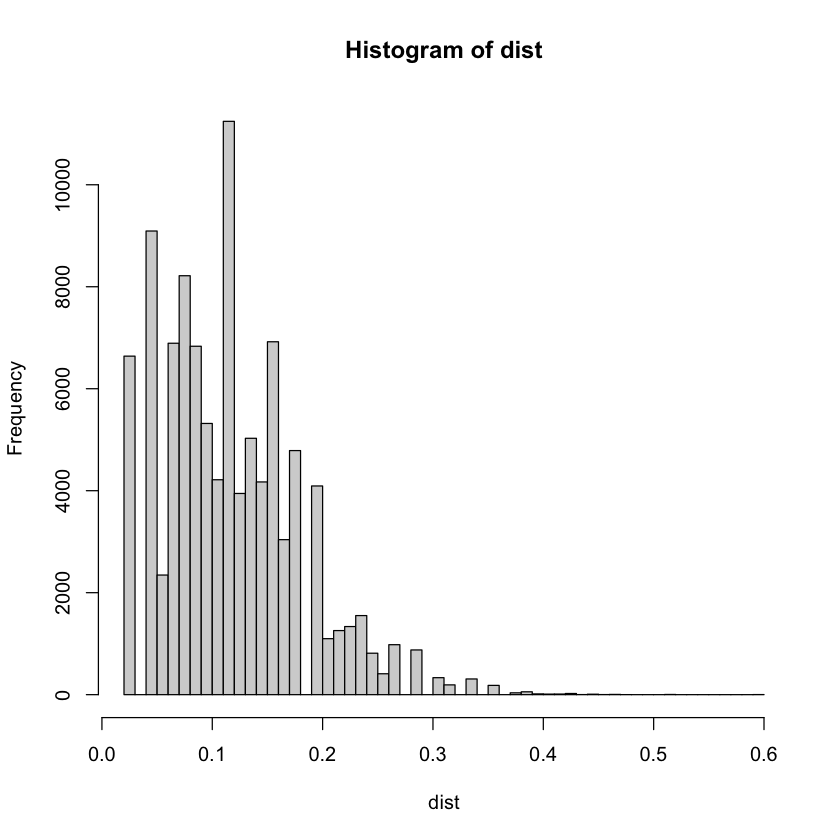

In [9]:
hist(dist, breaks = 50)
summary(dist)

# Visualización de la distribución de distancias

Este script genera un histograma de las distancias normalizadas entre secuencias e incorpora el umbral de clonación estimado previamente mediante el modelo GMM.

## Librería utilizada

* **ggplot2**: paquete utilizado para la creación de gráficos.

---

## Obtención del umbral

```r
threshold <- out@threshold
```

Extrae el valor del umbral de clonación calculado previamente, el cual será representado en el gráfico.

---

## Creación del histograma

```r
ggplot(data.frame(dist = dist), aes(x = dist))
```

Se construye un gráfico utilizando las distancias normalizadas entre cada secuencia y su vecino más cercano.

* **geom_histogram()**: representa la distribución de frecuencias de las distancias.
* **binwidth = 0.02**: define el ancho de cada intervalo del histograma.
* **color = "white"**: dibuja un borde blanco alrededor de cada barra para facilitar su visualización.

---

## Representación del umbral

```r
geom_vline(...)
```

Añade una línea vertical discontinua en la posición del umbral de clonación.

* **xintercept = threshold**: posición de la línea.
* **color = "firebrick"**: color de la línea.
* **linetype = 2**: línea discontinua.

---

## Personalización del gráfico

* **labs()**: define las etiquetas de los ejes.
* **scale_x_continuous()**: fija el rango del eje X entre 0 y 1 y establece marcas cada 0.1 unidades.
* **theme_bw()**: aplica un tema de fondo blanco para mejorar la legibilidad del gráfico.

---

## Resultado

El histograma permite visualizar la distribución de las distancias normalizadas entre secuencias y verificar gráficamente la posición del umbral de clonación estimado por el modelo GMM.


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


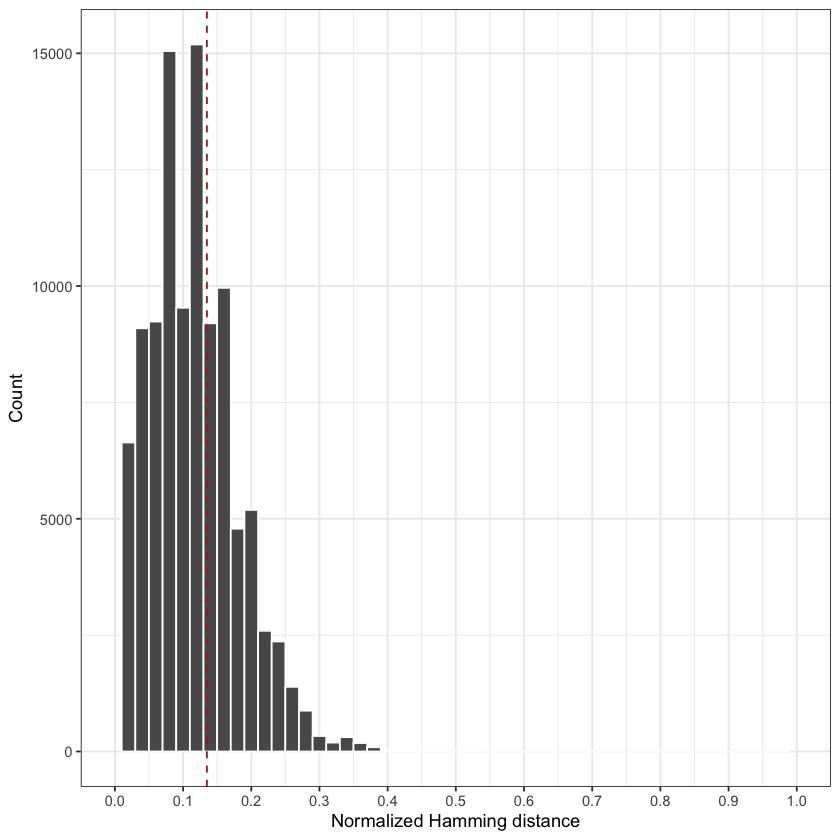

In [10]:
library(ggplot2)

threshold <- out@threshold

p1 <- ggplot(data.frame(dist = dist), aes(x = dist)) +
  geom_histogram(
    color = "white",
    binwidth = 0.02
  ) +
  geom_vline(
    xintercept = threshold,
    color = "firebrick",
    linetype = 2
  ) +
  labs(
    x = "Normalized Hamming distance",
    y = "Count"
  ) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.1),
    limits = c(0, 1)
  ) +
  theme_bw()

p1

In [24]:
library(shazam)
library(ggplot2)
library(grid)
ruta_base <- "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output"

sizes <- c(100,200,400,800,1600,3200,6400,12800,25600,51200)

mi_lista <- list()

for(n in sizes){

  archivo <- paste0(
    ruta_base,
    "/repertorio_D_insilico_",
    n,
    "_seqs_db-pass.tsv"
  )

  db <- read.delim(archivo)

  
  dist_obj <- distToNearest(
    db,
    vCallColumn = "v_call",
    jCallColumn = "j_call",
    model = "ham",
    normalize = "len"
  )

  d <- dist_obj$dist_nearest

 

   grafico <-  ggplot(data.frame(dist = d), aes(x = dist)) +
      geom_histogram(binwidth = 0.02, color = "white") +
      labs(
        title = paste0("n = ", n),
        x = "Normalized Hamming distance",
        y = "Count"
      ) +
      scale_x_continuous(limits = c(0, 1)) +
      theme_bw()

mi_lista <- append(mi_lista, grafico)
}

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
Running in non-single-cell mode.

Warning message in max(el[, 3]

Warning message:
"Removed 47 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 58 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 83 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 93 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 100 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outsi

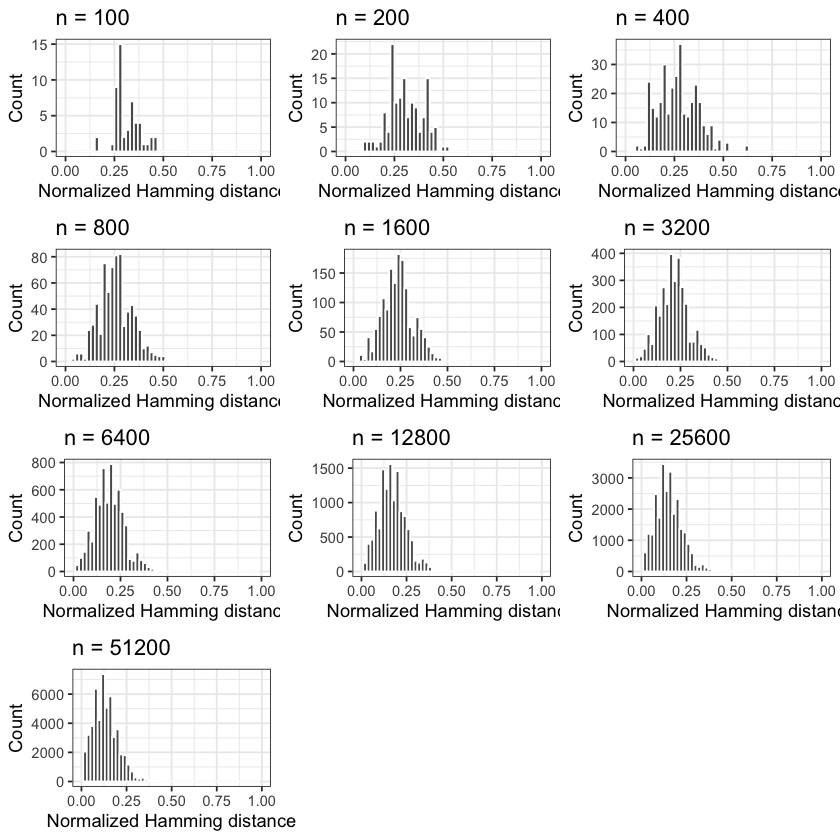

In [25]:
library(gridExtra)

grid.arrange(grobs = mi_lista,
        , ncol = 3)

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 102372 >= max_n{n in table} = 72000 -- using that as asymptotic value.



A <U+2192> umbral: 0.1048131 


Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 101999 >= max_n{n in table} = 72000 -- using that as asymptotic value.



B <U+2192> umbral: 0.148159 


Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 102089 >= max_n{n in table} = 72000 -- using that as asymptotic value.



...

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 102299 >= max_n{n in table} = 72000 -- using that as asymptotic value.



D <U+2192> umbral: 0.1349661 


Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"
n = 102214 >= max_n{n in table} = 72000 -- using that as asymptotic value.



E <U+2192> umbral: 0.2523345 


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


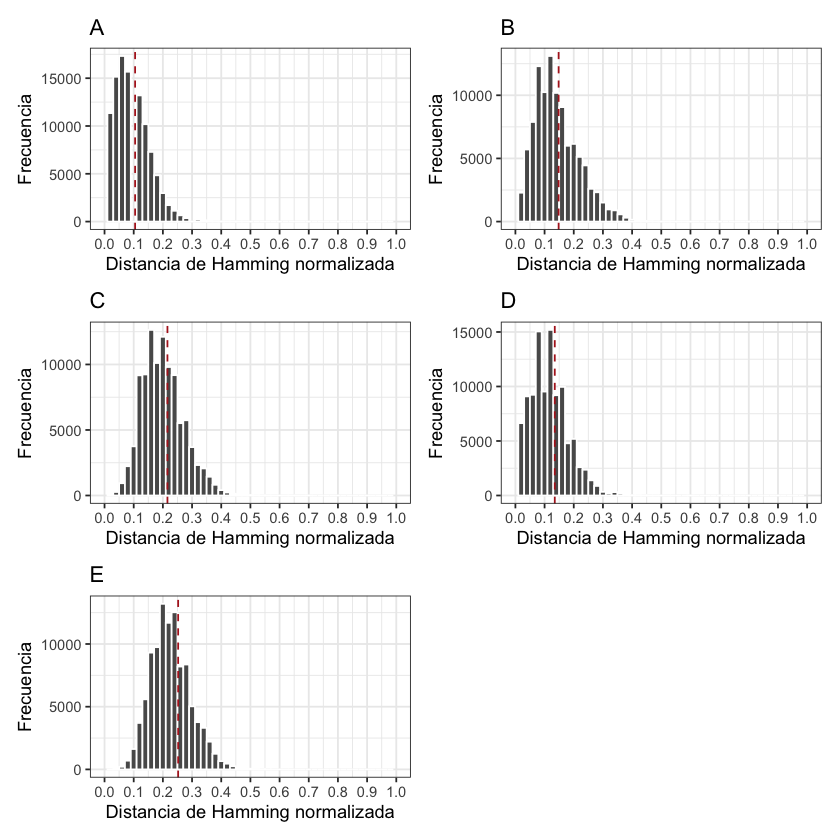

In [3]:
library(shazam)
library(ggplot2)
library(patchwork)


# 1. Carpeta

carpeta <- "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output"


# 2. Archivos


archivos <- c(
  "repertorio_A_insilico_102400_seqs_db-pass.tsv",
  "repertorio_B_insilico_102400_seqs_db-pass.tsv",
  "repertorio_C_insilico_102400_seqs_db-pass.tsv",
  "repertorio_D_insilico_102400_seqs_db-pass.tsv",
  "repertorio_E_insilico_102400_seqs_db-pass.tsv"
)


# 3. Nombres


nombres <- c(
  "A",
  "B",
  "C",
  "D",
  "E"
)


# 4. Crear lista de gráficos


graficos <- list()

# 5. Procesar los 5 escenarios


for (i in seq_along(archivos)) {

  # Cargar base
  

  db <- read.table(
    file.path(carpeta, archivos[i]),
    header = TRUE,
    sep = "\t"
  )

  # Calcular distancias

  dist <- distToNearest(
    db,
    sequenceColumn = "junction",
    vCallColumn = "v_call",
    jCallColumn = "j_call",
    model = "ham",
    normalize = "len"
  )$dist_nearest

  # Eliminar NA


  dist <- dist[!is.na(dist)]

  # GMM

  out <- findThreshold(
    dist,
    method = "gmm",
    model = "norm-norm",
    cutoff = "optimal"
  )

  # Umbral
  threshold <- out@threshold


  # Mostrar umbral
  cat(
    nombres[i],
    "→ umbral:",
    threshold,
    "\n"
  )

  # Crear gráfico

  p <- ggplot(
    data.frame(dist = dist),
    aes(x = dist)
  ) +

    geom_histogram(
      color = "white",
      binwidth = 0.02
    ) +

    geom_vline(
      xintercept = threshold,
      color = "firebrick",
      linetype = 2
    ) +

    labs(
      title = nombres[i],
      x = "Distancia de Hamming normalizada",
      y = "Frecuencia"
    ) +

    scale_x_continuous(
      breaks = seq(0, 1, 0.1),
      limits = c(0, 1)
    ) +

    theme_bw()


  # Guardar gráfico
  graficos[[i]] <- p
}

# 6. Unir los 5 gráficos

figura_final <- (
  graficos[[1]] +
  graficos[[2]] +
  graficos[[3]] +
  graficos[[4]] +
  graficos[[5]]
) +
  plot_layout(ncol = 2)


# Mostrar
figura_final